# Crop Yield Prediction — Sugarcane

**Objective**: Predict `rendement_tha` (yield in tonnes/hectare) per parcel and minimize MAPE.

**Dataset**: 194 dev parcels (with spatial CV folds) + 49 hold parcels, 201 features.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
import warnings

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.utils import resample
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [2]:
path = "TomateProduction"

In [3]:
dev  = pd.read_csv(f"{path}/dev_set_07.csv")
hold = pd.read_csv(f"{path}/hold_set_07.csv")

print(f"Dev set  : {dev.shape[0]} rows x {dev.shape[1]} columns")
print(f"Hold set : {hold.shape[0]} rows x {hold.shape[1]} columns")

TARGET = 'rendement_tha'
META   = ['polygon_id', 'polygon_name', 'kfold']
DROP   = META + [TARGET]

Dev set  : 194 rows x 205 columns
Hold set : 49 rows x 204 columns


---
## 2. Data Understanding (EDA)

### 2.1 Target Distribution

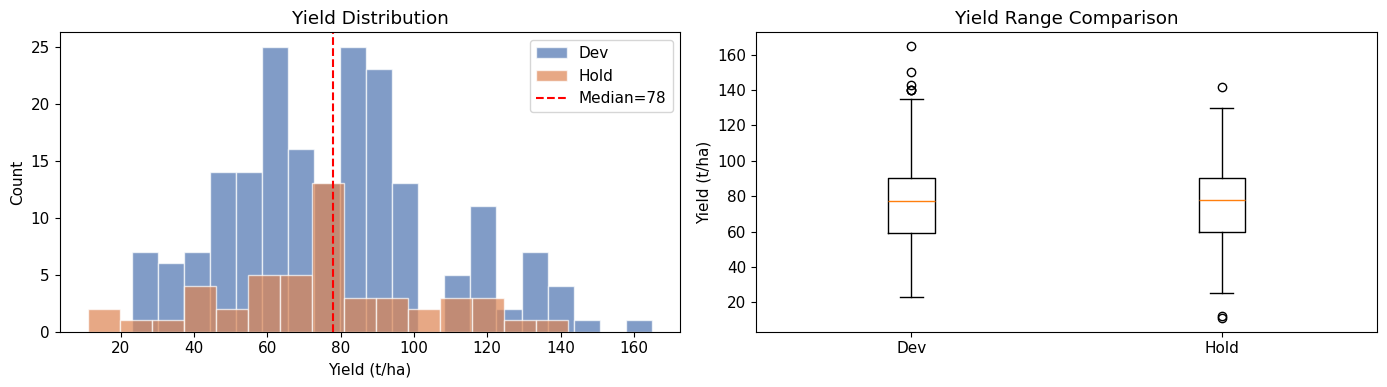

                       Dev       Hold        All
Mean                  77.9       75.4       77.4
Median                77.0       78.0       78.0
Std                   28.4       28.8       28.4
Min                   23.0       11.0       11.0
Max                  165.0      142.0      165.0


In [4]:
all_yield = pd.concat([dev[TARGET], hold[TARGET]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(dev[TARGET], bins=20, alpha=0.7, label='Dev', color='#4C72B0', edgecolor='white')
axes[0].hist(hold[TARGET], bins=15, alpha=0.7, label='Hold', color='#DD8452', edgecolor='white')
axes[0].axvline(all_yield.median(), color='red', linestyle='--', label=f'Median={all_yield.median():.0f}')
axes[0].set_xlabel('Yield (t/ha)')
axes[0].set_ylabel('Count')
axes[0].set_title('Yield Distribution')
axes[0].legend()

# Boxplot
axes[1].boxplot([dev[TARGET], hold[TARGET]], labels=['Dev', 'Hold'])
axes[1].set_ylabel('Yield (t/ha)')
axes[1].set_title('Yield Range Comparison')

plt.tight_layout()
plt.show()

print(f"{'':15s} {'Dev':>10s} {'Hold':>10s} {'All':>10s}")
for stat, fn in [('Mean', 'mean'), ('Median', 'median'), ('Std', 'std'), ('Min', 'min'), ('Max', 'max')]:
    print(f"{stat:15s} {getattr(dev[TARGET], fn)():10.1f} {getattr(hold[TARGET], fn)():10.1f} {getattr(all_yield, fn)():10.1f}")

### 2.2 Feature Groups Overview

The 201 features fall into these categories:

| Category | Description | Suffix pattern | Approx count |
|----------|-------------|----------------|--------------|
| **Soil** | Physical/chemical soil properties | `awc`, `bdod`, `cec`, `cfvo`, `clay`, `nitrogen`, `ocd`, `phh2o`, `sand`, `silt`, `soc` | ~11 |
| **Vegetation indices** | NDVI, EVI, DSWI, NDWI, NRI, GNDVI, SAVI, MSAVI, etc. | `*_mean_s{1-4}`, `*_max_s{1-4}`, `*_std_s{1-4}` | ~120 |
| **Climate / Meteo** | Temperature, humidity, precipitation, ET0, GDD | `temp_*`, `humidity_*`, `precip_*`, `et0_*`, `gdd_*` | ~50 |
| **Stress indicators** | Drought frequency, water stress | `stress_hydrique_*`, `freq_secheresse_*` | ~10 |
| **Temporal deltas** | Season-to-season changes | `delta_*_s{N}_vs_s{M}` | ~8 |
| **Geometry** | Parcel area | `area_polygon` | 1 |

Seasons: **s1** (early), **s2** (mid-early), **s3** (mid-late), **s4** (late growth).

All features appear to be **pre-standardized** (z-scores centered around 0).

In [5]:
# Programmatic feature grouping
features = [c for c in dev.columns if c not in DROP]

soil_kw = ['awc','bdod','cec','cfvo','clay','nitrogen','ocd','phh2o','sand','silt','soc','indice_texture']
groups = {'Soil': [], 'Vegetation': [], 'Climate': [], 'Stress': [], 'Delta': [], 'Geometry': [], 'Other': []}

for f in features:
    if any(f.startswith(s) for s in soil_kw):
        groups['Soil'].append(f)
    elif f.startswith('delta_'):
        groups['Delta'].append(f)
    elif any(kw in f for kw in ['stress','secheresse']):
        groups['Stress'].append(f)
    elif any(kw in f for kw in ['temp','humidity','precip','et0','gdd','cloud','wind','intensite_chaleur','radiation']):
        groups['Climate'].append(f)
    elif f == 'area_polygon':
        groups['Geometry'].append(f)
    elif any(kw in f for kw in ['ndvi','evi','dswi','ndwi','nri','gndvi','savi','msavi','nri','inter_']):
        groups['Vegetation'].append(f)
    else:
        groups['Other'].append(f)

print(f"{'Group':15s} {'Count':>6s}")
print('-' * 25)
for g, cols in groups.items():
    if cols:
        print(f"{g:15s} {len(cols):6d}")
print(f"{'TOTAL':15s} {len(features):6d}")

if groups['Other']:
    print(f"\nUncategorized: {groups['Other']}")

Group            Count
-------------------------
Soil                11
Vegetation          65
Climate             68
Stress              24
Delta                8
Geometry             1
Other               24
TOTAL              201

Uncategorized: ['ratio_sand_clay', 'soil_moisture_s1', 'soil_moisture_s2', 'soil_moisture_s3', 'soil_moisture_s4', 'solar_cum_s1', 'solar_cum_s2', 'solar_cum_s3', 'solar_cum_s4', 'bern_chaleur_extreme_s3', 'bern_chaleur_extreme_s4', 'bern_chaleur_forte_s2', 'bern_chaleur_forte_s3', 'bern_chaleur_forte_s4', 'bern_froid_s2', 'bern_froid_s3', 'bern_froid_s4', 'loi_phys_froid_s1', 'loi_phys_chaleur_s3', 'loi_phys_yield_extreme', 'score_global_s3', 'score_global_s4', 'score_humid_s1', 'score_humid_s4']


### 2.3 Top Features Correlated with Yield

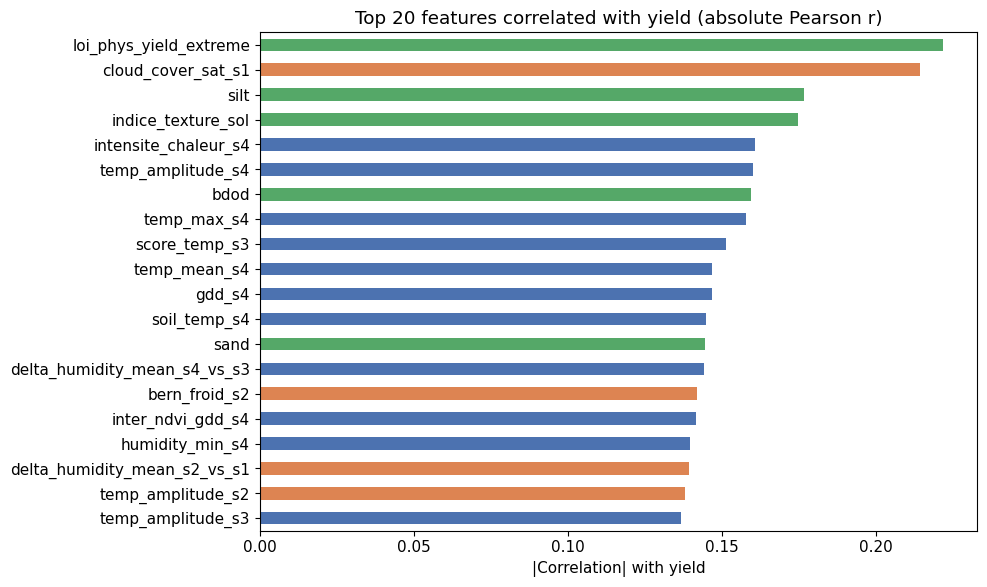


Top 20 features:
   1. + loi_phys_yield_extreme                        r = 0.222
   2. + cloud_cover_sat_s1                            r = 0.214
   3. - silt                                          r = 0.177
   4. - indice_texture_sol                            r = 0.175
   5. - intensite_chaleur_s4                          r = 0.161
   6. - temp_amplitude_s4                             r = 0.160
   7. + bdod                                          r = 0.159
   8. - temp_max_s4                                   r = 0.158
   9. - score_temp_s3                                 r = 0.151
  10. - temp_mean_s4                                  r = 0.147
  11. - gdd_s4                                        r = 0.147
  12. - soil_temp_s4                                  r = 0.145
  13. + sand                                          r = 0.145
  14. + delta_humidity_mean_s4_vs_s3                  r = 0.144
  15. - bern_froid_s2                                 r = 0.142
  16. + inter_ndvi_gdd

In [6]:
correlations = dev[features].corrwith(dev[TARGET]).abs().sort_values(ascending=False)
top20 = correlations.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4C72B0' if 's3' in f or 's4' in f else '#DD8452' if 's1' in f or 's2' in f else '#55A868' for f in top20.index]
top20.plot.barh(ax=ax, color=colors)
ax.set_xlabel('|Correlation| with yield')
ax.set_title('Top 20 features correlated with yield (absolute Pearson r)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
for i, (feat, corr) in enumerate(top20.items(), 1):
    sign = '+' if dev[feat].corr(dev[TARGET]) > 0 else '-'
    print(f"  {i:2d}. {sign} {feat:45s} r = {corr:.3f}")

### 2.4 Feature Distributions by Yield Class

Yield thresholds: faible < 64.9 < moyen < 87.0 < fort

Class distribution (dev):


classe
fort      67
moyen     64
faible    63
Name: count, dtype: int64


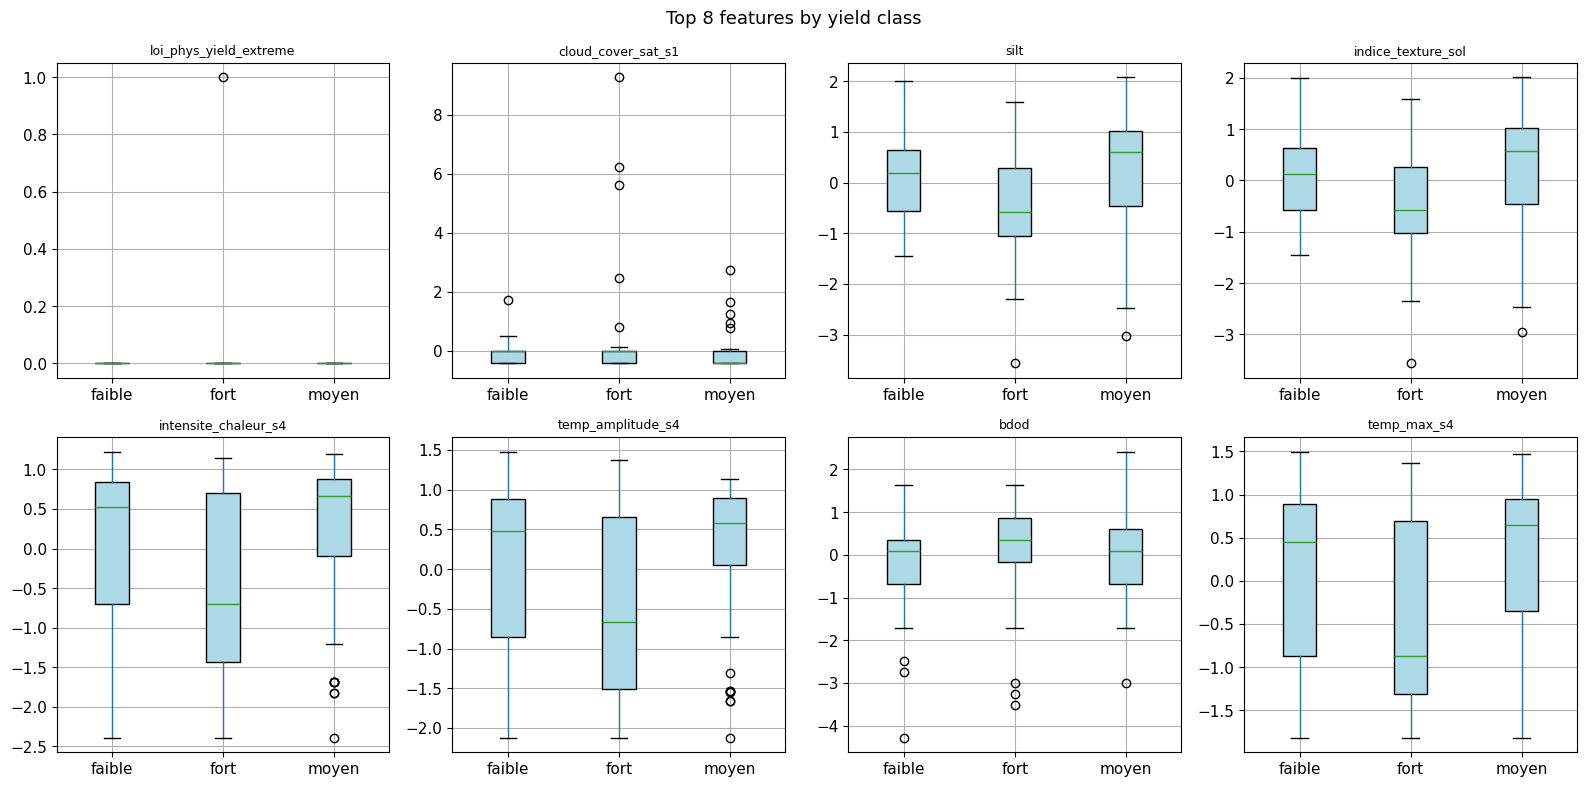

In [7]:
# Define yield classes
low_q  = all_yield.quantile(0.33)
high_q = all_yield.quantile(0.67)

def yield_class(val):
    if val < low_q:    return 'faible'
    elif val < high_q: return 'moyen'
    else:              return 'fort'

dev['classe'] = dev[TARGET].apply(yield_class)

print(f"Yield thresholds: faible < {low_q:.1f} < moyen < {high_q:.1f} < fort")
print(f"\nClass distribution (dev):")
print(dev['classe'].value_counts())

# Boxplots of top 8 features by class
top8 = correlations.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.flat, top8):
    dev.boxplot(column=feat, by='classe', ax=ax,
                positions=[0, 1, 2],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Top 8 features by yield class', fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 Seasonal Vegetation Patterns

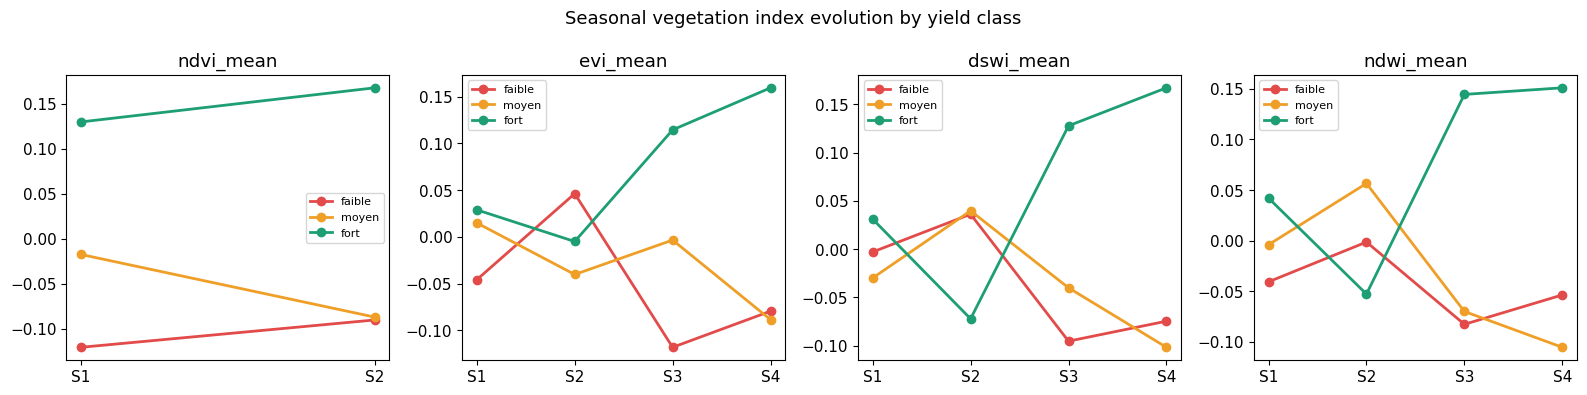

In [8]:
# Track how key vegetation indices evolve from s1 to s4 by yield class
indices = ['ndvi_mean', 'evi_mean', 'dswi_mean', 'ndwi_mean']
seasons = ['s1', 's2', 's3', 's4']
class_colors = {'faible': '#E24B4A', 'moyen': '#EF9F27', 'fort': '#1D9E75'}

fig, axes = plt.subplots(1, len(indices), figsize=(16, 4))
for ax, idx_name in zip(axes, indices):
    cols = [f"{idx_name}_{s}" for s in seasons]
    existing = [c for c in cols if c in dev.columns]
    if not existing:
        ax.set_title(f"{idx_name} (not found)")
        continue
    for classe in ['faible', 'moyen', 'fort']:
        subset = dev[dev['classe'] == classe]
        means = [subset[c].mean() for c in existing]
        ax.plot(range(len(existing)), means, 'o-',
                color=class_colors[classe], label=classe, linewidth=2)
    ax.set_xticks(range(len(existing)))
    ax.set_xticklabels([s.upper() for s in seasons[:len(existing)]])
    ax.set_title(idx_name)
    ax.legend(fontsize=8)

plt.suptitle('Seasonal vegetation index evolution by yield class', fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 Missing Values & Data Quality

In [9]:
missing_dev  = dev[features].isnull().sum()
missing_hold = hold[[c for c in features if c in hold.columns]].isnull().sum()

missing_dev  = missing_dev[missing_dev > 0]
missing_hold = missing_hold[missing_hold > 0]

if len(missing_dev) == 0 and len(missing_hold) == 0:
    print("No missing values in either set.")
else:
    print("Missing values (dev):")
    print(missing_dev)
    print("\nMissing values (hold):")
    print(missing_hold)

# Check column alignment
dev_feats  = set(dev.columns) - set(DROP) - {'classe'}
hold_feats = set(hold.columns) - set([c for c in DROP if c in hold.columns])
only_dev  = dev_feats - hold_feats
only_hold = hold_feats - dev_feats
print(f"\nFeatures in dev only  : {only_dev if only_dev else 'none'}")
print(f"Features in hold only : {only_hold if only_hold else 'none'}")

No missing values in either set.

Features in dev only  : none
Features in hold only : none


In [10]:
# Clean up temporary column
dev.drop(columns=['classe'], inplace=True, errors='ignore')

---
## 3. Merge Datasets & Proper Stratified CV

The original split has a distribution mismatch — the hold set contains yield ranges underrepresented in training (especially low-yield parcels). We merge both sets and create stratified K-fold splits so every fold sees the full yield range.

In [11]:
from sklearn.model_selection import StratifiedKFold

# Merge dev + hold into one dataset
# Align hold columns to dev first
hold_aligned = hold.reindex(columns=dev.columns, fill_value=0)
full = pd.concat([dev, hold_aligned], ignore_index=True)

print(f"Merged dataset: {full.shape[0]} rows x {full.shape[1]} columns")
print(f"  Dev parcels : {len(dev)}")
print(f"  Hold parcels: {len(hold)}")

# Feature / target split
feature_cols = [c for c in full.columns if c not in [TARGET] + META]
X_full = full[feature_cols]
y_full = full[TARGET]

# Track which rows came from hold set (for later evaluation)
full['source'] = ['dev'] * len(dev) + ['hold'] * len(hold)
hold_mask = full['source'] == 'hold'

# Create yield classes for stratification
all_y = y_full
low   = all_y.quantile(0.33)
high  = all_y.quantile(0.67)

def yield_class(val):
    if val < low:    return 'faible'
    elif val < high: return 'moyen'
    else:            return 'fort'

y_classes = y_full.apply(yield_class)

# Stratified K-Fold (5 folds, stratified by yield class)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
full['fold'] = -1
for fold_id, (_, val_idx) in enumerate(skf.split(X_full, y_classes)):
    full.loc[val_idx, 'fold'] = fold_id

print(f"\nYield classes: faible < {low:.1f} < moyen < {high:.1f} < fort")
print(f"\nClass distribution per fold:")
for f in range(5):
    fold_y = y_full[full['fold'] == f]
    counts = fold_y.apply(yield_class).value_counts()
    print(f"  Fold {f}: {dict(counts)}, n={len(fold_y)}")

Merged dataset: 243 rows x 205 columns
  Dev parcels : 194
  Hold parcels: 49

Yield classes: faible < 64.9 < moyen < 87.0 < fort

Class distribution per fold:
  Fold 0: {'fort': np.int64(17), 'faible': np.int64(16), 'moyen': np.int64(16)}, n=49
  Fold 1: {'moyen': np.int64(17), 'fort': np.int64(16), 'faible': np.int64(16)}, n=49
  Fold 2: {'moyen': np.int64(17), 'faible': np.int64(16), 'fort': np.int64(16)}, n=49
  Fold 3: {'moyen': np.int64(16), 'faible': np.int64(16), 'fort': np.int64(16)}, n=48
  Fold 4: {'moyen': np.int64(16), 'fort': np.int64(16), 'faible': np.int64(16)}, n=48


Features with >80% same value → DROPPED (14 features):
Feature                                  Dominant %
----------------------------------------------------
  loi_phys_froid_s1                         100.0%  (value=0)
  loi_phys_chaleur_s3                       100.0%  (value=0)
  loi_phys_gdd_faible                       100.0%  (value=0)
  loi_phys_yield_extreme                     99.6%  (value=0)
  flag_anomalie_ndvi_s4                      98.8%  (value=0)
  flag_anomalie_ndvi_s3                      96.7%  (value=0)
  flag_anomalie_ndvi_s2                      96.3%  (value=0)
  flag_anomalie_ndvi_s1                      93.8%  (value=0)
  loi_phys_gdd_anomalie_z                    92.6%  (value=0)
  bern_stress_extreme_s2                     90.9%  (value=0)
  bern_stress_extreme_s4                     90.9%  (value=0)
  bern_chaleur_extreme_s3                    90.1%  (value=0)
  bern_stress_extreme_s3                     90.1%  (value=0)
  bern_chaleur_extreme_s4         

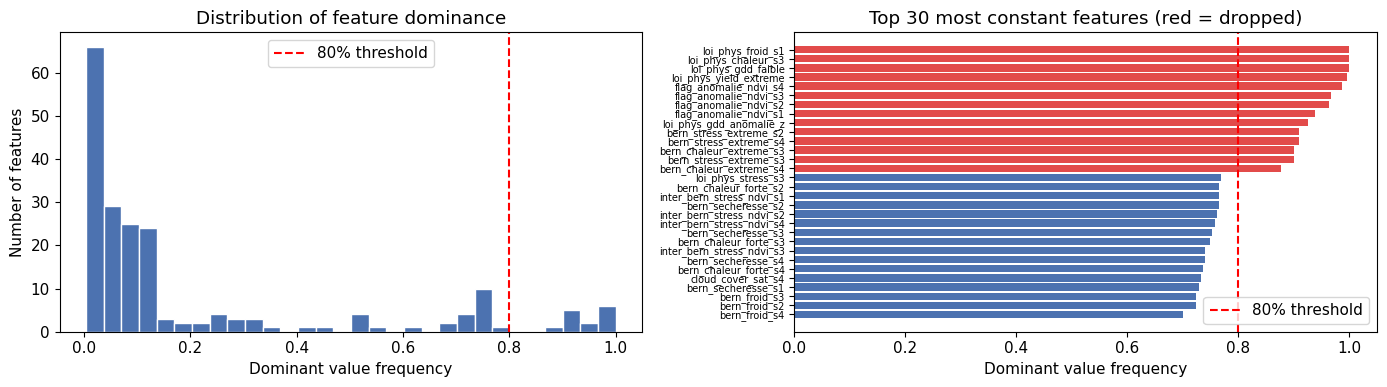

In [12]:
# ── Remove near-constant features (>80% same value) ──────────────────────────
threshold = 0.80

dominance = {}
for col in feature_cols:
    top_freq = X_full[col].value_counts(normalize=True).iloc[0]
    dominance[col] = top_freq

dominance_series = pd.Series(dominance).sort_values(ascending=False)
to_drop = dominance_series[dominance_series > threshold].index.tolist()

print(f"Features with >{threshold*100:.0f}% same value → DROPPED ({len(to_drop)} features):")
print(f"{'Feature':<40s} {'Dominant %':>10s}")
print('-' * 52)
for col in to_drop:
    top_val = X_full[col].value_counts().index[0]
    print(f"  {col:<38s} {dominance[col]*100:>8.1f}%  (value={top_val})")

# Apply the filter
feature_cols = [c for c in feature_cols if c not in to_drop]
X_full = full[feature_cols]

print(f"\nFeatures before : {len(to_drop) + len(feature_cols)}")
print(f"Features dropped: {len(to_drop)}")
print(f"Features kept   : {len(feature_cols)}")

# Visualize dominance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dominance_series.values, bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'{threshold*100:.0f}% threshold')
axes[0].set_xlabel('Dominant value frequency')
axes[0].set_ylabel('Number of features')
axes[0].set_title('Distribution of feature dominance')
axes[0].legend()

top30 = dominance_series.head(30)
colors = ['#E24B4A' if v > threshold else '#4C72B0' for v in top30.values]
axes[1].barh(range(len(top30)), top30.values, color=colors)
axes[1].set_yticks(range(len(top30)))
axes[1].set_yticklabels(top30.index, fontsize=7)
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'{threshold*100:.0f}% threshold')
axes[1].invert_yaxis()
axes[1].set_xlabel('Dominant value frequency')
axes[1].set_title('Top 30 most constant features (red = dropped)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# Oversample faible class (3x) on the merged dataset
full_aug = full.copy()
faible_rows = full_aug[full_aug[TARGET] < low]

faible_upsampled = resample(
    faible_rows, replace=True,
    n_samples=len(faible_rows) * 3,
    random_state=42
)
full_aug = pd.concat([full_aug, faible_upsampled]).reset_index(drop=True)

X_aug    = full_aug[feature_cols]
y_aug    = full_aug[TARGET]
fold_aug = full_aug['fold']

print("Class counts after 3x oversampling of faible:")
print(full_aug[TARGET].apply(yield_class).value_counts())

Class counts after 3x oversampling of faible:
rendement_tha
faible    320
moyen      82
fort       81
Name: count, dtype: int64


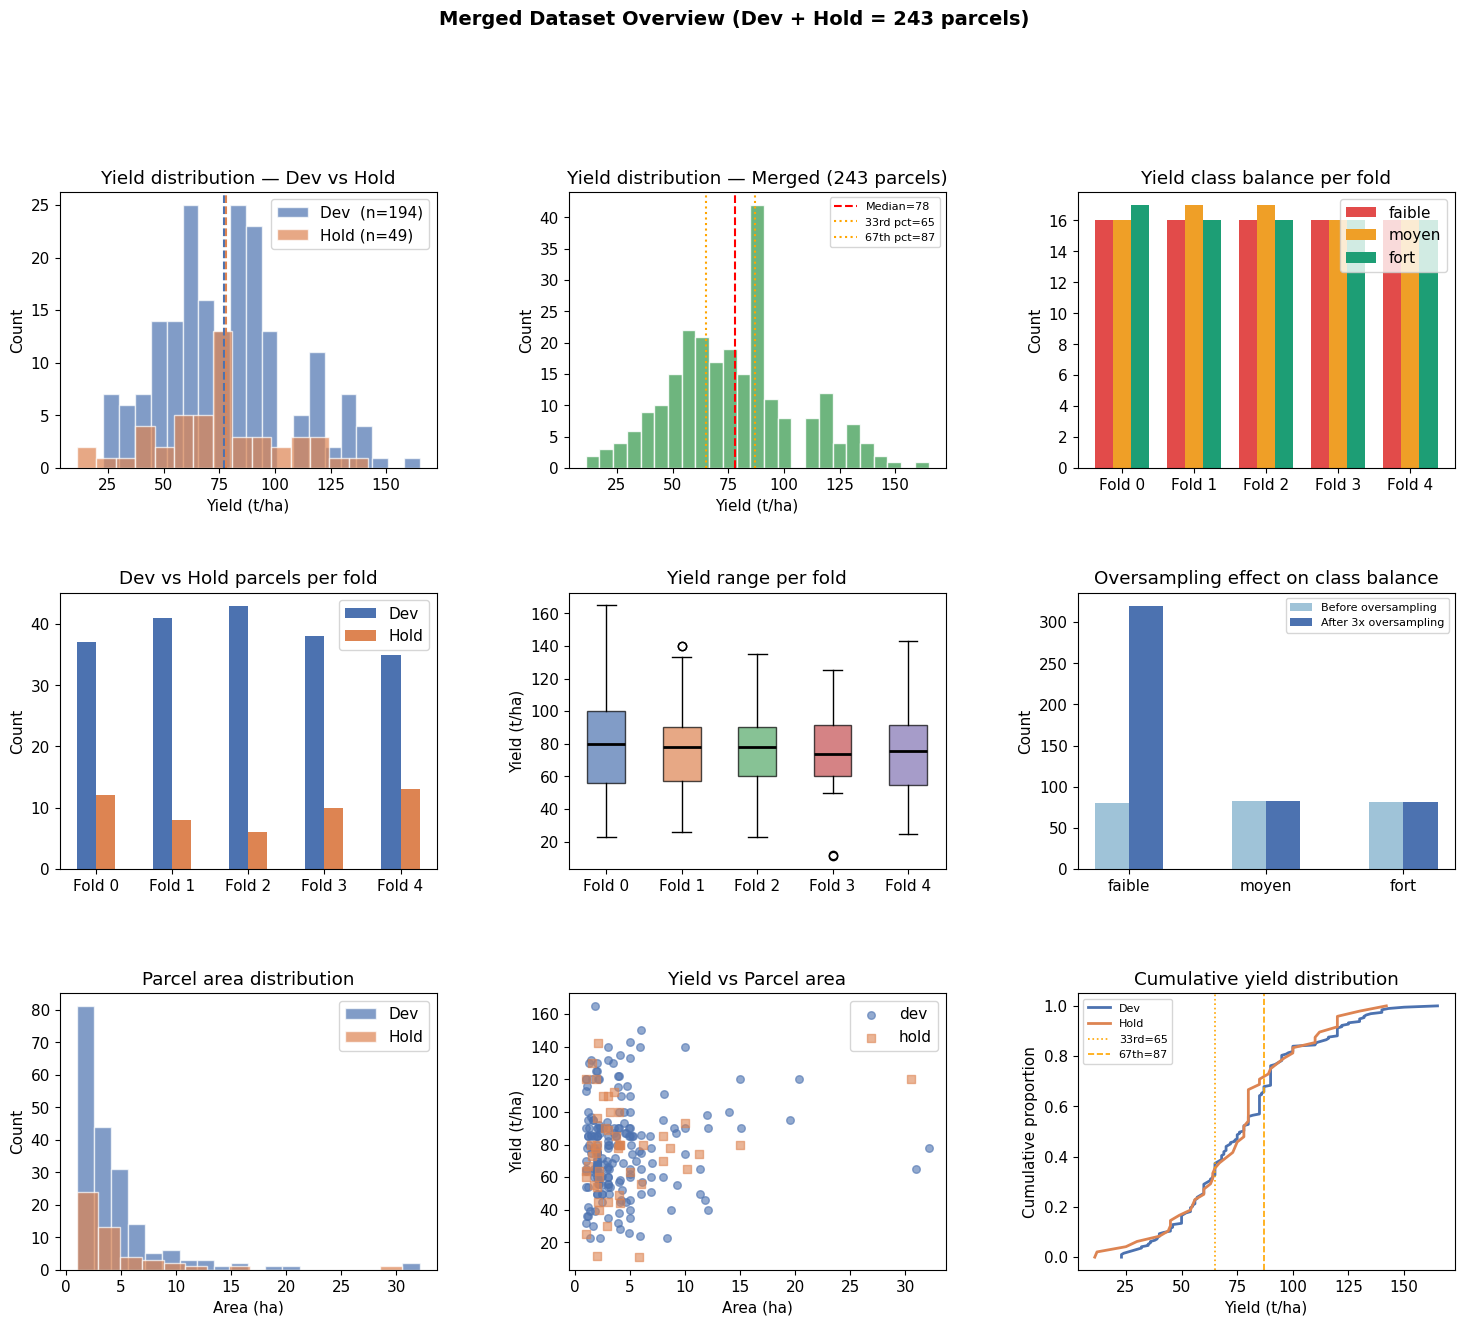

                            Dev       Hold     Merged
--------------------------------------------------
Count                     194.0       49.0      243.0
Mean                       77.9       75.4       77.4
Median                     77.0       78.0       78.0
Std                        28.4       28.8       28.4
Min                        23.0       11.0       11.0
Max                       165.0      142.0      165.0


In [14]:

# ── Merged Dataset Visualizations ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── 1. Yield distribution: dev vs hold ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(dev[TARGET],  bins=20, alpha=0.7, color='#4C72B0', label=f'Dev  (n={len(dev)})',  edgecolor='white')
ax1.hist(hold[TARGET], bins=15, alpha=0.7, color='#DD8452', label=f'Hold (n={len(hold)})', edgecolor='white')
ax1.axvline(dev[TARGET].median(),  color='#4C72B0', linestyle='--', linewidth=1.5)
ax1.axvline(hold[TARGET].median(), color='#DD8452', linestyle='--', linewidth=1.5)
ax1.set_title('Yield distribution — Dev vs Hold')
ax1.set_xlabel('Yield (t/ha)')
ax1.set_ylabel('Count')
ax1.legend()

# ── 2. Yield distribution after merge ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(y_full, bins=25, color='#55A868', edgecolor='white', alpha=0.85)
ax2.axvline(y_full.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={y_full.median():.0f}')
ax2.axvline(low,  color='orange', linestyle=':', linewidth=1.5, label=f'33rd pct={low:.0f}')
ax2.axvline(high, color='orange', linestyle=':', linewidth=1.5, label=f'67th pct={high:.0f}')
ax2.set_title('Yield distribution — Merged (243 parcels)')
ax2.set_xlabel('Yield (t/ha)')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)

# ── 3. Yield class balance across folds ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
class_counts = pd.DataFrame(index=range(5), columns=['faible','moyen','fort'], dtype=int)
for f in range(5):
    fold_classes = y_full[full['fold'] == f].apply(yield_class).value_counts()
    for c in ['faible','moyen','fort']:
        class_counts.loc[f, c] = fold_classes.get(c, 0)

x     = np.arange(5)
width = 0.25
ax3.bar(x - width, class_counts['faible'], width, label='faible', color='#E24B4A')
ax3.bar(x,         class_counts['moyen'],  width, label='moyen',  color='#EF9F27')
ax3.bar(x + width, class_counts['fort'],   width, label='fort',   color='#1D9E75')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Fold {i}' for i in range(5)])
ax3.set_title('Yield class balance per fold')
ax3.set_ylabel('Count')
ax3.legend()

# ── 4. Dev vs Hold parcels per fold ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
dev_per_fold  = [sum((full['fold'] == f) & (full['source'] == 'dev'))  for f in range(5)]
hold_per_fold = [sum((full['fold'] == f) & (full['source'] == 'hold')) for f in range(5)]
ax4.bar(x - width/2, dev_per_fold,  width, label='Dev',  color='#4C72B0')
ax4.bar(x + width/2, hold_per_fold, width, label='Hold', color='#DD8452')
ax4.set_xticks(x)
ax4.set_xticklabels([f'Fold {i}' for i in range(5)])
ax4.set_title('Dev vs Hold parcels per fold')
ax4.set_ylabel('Count')
ax4.legend()

# ── 5. Yield boxplot per fold ──────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
fold_yields = [y_full[full['fold'] == f].values for f in range(5)]
bp = ax5.boxplot(fold_yields, labels=[f'Fold {i}' for i in range(5)],
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_title('Yield range per fold')
ax5.set_ylabel('Yield (t/ha)')

# ── 6. Effect of oversampling on class balance ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
before = y_full.apply(yield_class).value_counts().reindex(['faible','moyen','fort'])
after  = y_aug.apply(yield_class).value_counts().reindex(['faible','moyen','fort'])
x2     = np.arange(3)
ax6.bar(x2 - width/2, before.values, width, label='Before oversampling', color='#9FC3D8')
ax6.bar(x2 + width/2, after.values,  width, label='After 3x oversampling', color='#4C72B0')
ax6.set_xticks(x2)
ax6.set_xticklabels(['faible','moyen','fort'])
ax6.set_title('Oversampling effect on class balance')
ax6.set_ylabel('Count')
ax6.legend(fontsize=8)

# ── 7. Parcel area distribution by source ─────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
ax7.hist(dev['area_polygon'],  bins=20, alpha=0.7, color='#4C72B0', label='Dev',  edgecolor='white')
ax7.hist(hold['area_polygon'], bins=15, alpha=0.7, color='#DD8452', label='Hold', edgecolor='white')
ax7.set_title('Parcel area distribution')
ax7.set_xlabel('Area (ha)')
ax7.set_ylabel('Count')
ax7.legend()

# ── 8. Yield vs area scatter ───────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
for src, color, marker in [('dev','#4C72B0','o'), ('hold','#DD8452','s')]:
    mask = full['source'] == src
    ax8.scatter(full.loc[mask, 'area_polygon'], y_full[mask],
                color=color, marker=marker, alpha=0.6, s=30, label=src)
ax8.set_title('Yield vs Parcel area')
ax8.set_xlabel('Area (ha)')
ax8.set_ylabel('Yield (t/ha)')
ax8.legend()

# ── 9. Cumulative yield distribution ──────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
for src, color, label in [('dev','#4C72B0','Dev'), ('hold','#DD8452','Hold')]:
    vals = np.sort(y_full[full['source'] == src].values)
    ax9.plot(vals, np.linspace(0, 1, len(vals)), color=color, linewidth=2, label=label)
ax9.axvline(low,  color='orange', linestyle=':', linewidth=1.2, label=f'33rd={low:.0f}')
ax9.axvline(high, color='orange', linestyle='--', linewidth=1.2, label=f'67th={high:.0f}')
ax9.set_title('Cumulative yield distribution')
ax9.set_xlabel('Yield (t/ha)')
ax9.set_ylabel('Cumulative proportion')
ax9.legend(fontsize=8)

plt.suptitle('Merged Dataset Overview (Dev + Hold = 243 parcels)', fontsize=14, fontweight='bold', y=1.01)
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
print(f"{'':20s} {'Dev':>10s} {'Hold':>10s} {'Merged':>10s}")
print('-' * 50)
for stat, fn in [('Count','count'),('Mean','mean'),('Median','median'),('Std','std'),('Min','min'),('Max','max')]:
    print(f"{stat:20s} {getattr(dev[TARGET],fn)():10.1f} {getattr(hold[TARGET],fn)():10.1f} {getattr(y_full,fn)():10.1f}")


---
## 4. Model Training — LightGBM (Stratified CV on Merged Data)

In [15]:
params = {
    'objective'        : 'regression_l1',
    'metric'           : 'mape',
    'learning_rate'    : 0.03,
    'num_leaves'       : 20,
    'min_child_samples': 8,
    'feature_fraction' : 0.7,
    'bagging_fraction' : 0.7,
    'bagging_freq'     : 1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.5,
    'verbose'          : -1,
}

In [16]:
oof_preds = np.zeros(len(full))
models    = []

print("=== Stratified CV (LightGBM, oversampled, merged data) ===")
for fold_id in range(5):
    val_idx    = full[full['fold'] == fold_id].index
    train_mask = full_aug['fold'] != fold_id

    X_tr, y_tr   = X_aug[train_mask], y_aug[train_mask]
    X_val, y_val = X_full.loc[val_idx], y_full.loc[val_idx]

    model = lgb.LGBMRegressor(**params, n_estimators=1000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(80, verbose=False)]
    )

    preds = np.clip(model.predict(X_val), 0, None)
    oof_preds[val_idx] = preds
    models.append(model)

    mape = mean_absolute_percentage_error(y_val, preds) * 100
    print(f"  Fold {fold_id}: MAPE = {mape:.1f}%  (n={len(val_idx)})")

=== Stratified CV (LightGBM, oversampled, merged data) ===
  Fold 0: MAPE = 40.0%  (n=49)


  Fold 1: MAPE = 31.9%  (n=49)


  Fold 2: MAPE = 29.1%  (n=49)


  Fold 3: MAPE = 38.7%  (n=48)
  Fold 4: MAPE = 32.2%  (n=48)


In [17]:
# OOF MAPE — overall and broken down by class + source
results_oof = pd.DataFrame({
    'true': y_full, 'pred': oof_preds,
    'source': full['source'].values
})
results_oof['classe'] = results_oof['true'].apply(yield_class)

print("=== OOF MAPE by class (LightGBM, merged) ===")
for classe in ['faible', 'moyen', 'fort']:
    subset = results_oof[results_oof['classe'] == classe]
    mape   = mean_absolute_percentage_error(subset['true'], subset['pred']) * 100
    print(f"  {classe:8s}: MAPE = {mape:.1f}%  (n={len(subset)})")

global_mape = mean_absolute_percentage_error(y_full, oof_preds) * 100
print(f"  {'GLOBAL':8s}: MAPE = {global_mape:.1f}%")

# Breakdown by original source to compare
print("\n=== OOF MAPE by original source ===")
for src in ['dev', 'hold']:
    subset = results_oof[results_oof['source'] == src]
    mape = mean_absolute_percentage_error(subset['true'], subset['pred']) * 100
    print(f"  {src:8s}: MAPE = {mape:.1f}%  (n={len(subset)})")

# Detailed: hold parcels by class
print("\n=== OOF MAPE on hold parcels by class ===")
hold_oof = results_oof[results_oof['source'] == 'hold']
for classe in ['faible', 'moyen', 'fort']:
    subset = hold_oof[hold_oof['classe'] == classe]
    if len(subset) == 0: continue
    mape = mean_absolute_percentage_error(subset['true'], subset['pred']) * 100
    print(f"  {classe:8s}: MAPE = {mape:.1f}%  (n={len(subset)})")

=== OOF MAPE by class (LightGBM, merged) ===
  faible  : MAPE = 55.8%  (n=80)
  moyen   : MAPE = 13.9%  (n=82)
  fort    : MAPE = 33.9%  (n=81)
  GLOBAL  : MAPE = 34.4%

=== OOF MAPE by original source ===
  dev     : MAPE = 31.6%  (n=194)
  hold    : MAPE = 45.4%  (n=49)

=== OOF MAPE on hold parcels by class ===
  faible  : MAPE = 86.9%  (n=17)
  moyen   : MAPE = 14.6%  (n=18)
  fort    : MAPE = 34.4%  (n=14)


---
## 5. Model Training — Blended (LightGBM + Ridge)

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

oof_ridge    = np.zeros(len(full))
ridge_models = []

for fold_id in range(5):
    val_idx   = full[full['fold'] == fold_id].index
    train_idx = full[full['fold'] != fold_id].index

    ridge = Ridge(alpha=10)
    ridge.fit(X_scaled[train_idx], y_full.iloc[train_idx])
    oof_ridge[val_idx] = ridge.predict(X_scaled[val_idx])
    ridge_models.append(ridge)

# Blend: 70% LightGBM + 30% Ridge
BLEND_ALPHA = 0.7
oof_blend = BLEND_ALPHA * oof_preds + (1 - BLEND_ALPHA) * np.clip(oof_ridge, 0, None)

print("=== OOF MAPE — Blended (70% LightGBM + 30% Ridge) ===")
results_blend = pd.DataFrame({
    'true': y_full, 'pred': oof_blend,
    'source': full['source'].values
})
results_blend['classe'] = results_blend['true'].apply(yield_class)

for classe in ['faible', 'moyen', 'fort']:
    subset = results_blend[results_blend['classe'] == classe]
    mape   = mean_absolute_percentage_error(subset['true'], subset['pred']) * 100
    print(f"  {classe:8s}: MAPE = {mape:.1f}%  (n={len(subset)})")

print(f"  {'GLOBAL':8s}: MAPE = {mean_absolute_percentage_error(y_full, oof_blend) * 100:.1f}%")

# Hold parcels specifically
print("\n=== Blend MAPE on hold parcels ===")
hold_blend = results_blend[results_blend['source'] == 'hold']
for classe in ['faible', 'moyen', 'fort']:
    subset = hold_blend[hold_blend['classe'] == classe]
    if len(subset) == 0: continue
    mape = mean_absolute_percentage_error(subset['true'], subset['pred']) * 100
    print(f"  {classe:8s}: MAPE = {mape:.1f}%  (n={len(subset)})")
print(f"  {'GLOBAL':8s}: MAPE = {mean_absolute_percentage_error(hold_blend['true'], hold_blend['pred']) * 100:.1f}%")

=== OOF MAPE — Blended (70% LightGBM + 30% Ridge) ===
  faible  : MAPE = 62.4%  (n=80)
  moyen   : MAPE = 12.3%  (n=82)
  fort    : MAPE = 31.3%  (n=81)
  GLOBAL  : MAPE = 35.1%

=== Blend MAPE on hold parcels ===
  faible  : MAPE = 95.2%  (n=17)
  moyen   : MAPE = 10.7%  (n=18)
  fort    : MAPE = 31.2%  (n=14)
  GLOBAL  : MAPE = 45.9%


---
## 6. OOF Evaluation & Visualization

In [19]:
# Quantile models for confidence intervals (trained on full augmented data)
q_params = {**params, 'objective': 'quantile', 'metric': 'quantile'}
q_models = {}
for q, label in [(0.025, 'low'), (0.5, 'median'), (0.975, 'high')]:
    qm = lgb.LGBMRegressor(**q_params, alpha=q, n_estimators=1000)
    qm.fit(X_aug, y_aug)
    q_models[label] = qm
    print(f"Quantile {q} model trained")

Quantile 0.025 model trained


Quantile 0.5 model trained


Quantile 0.975 model trained


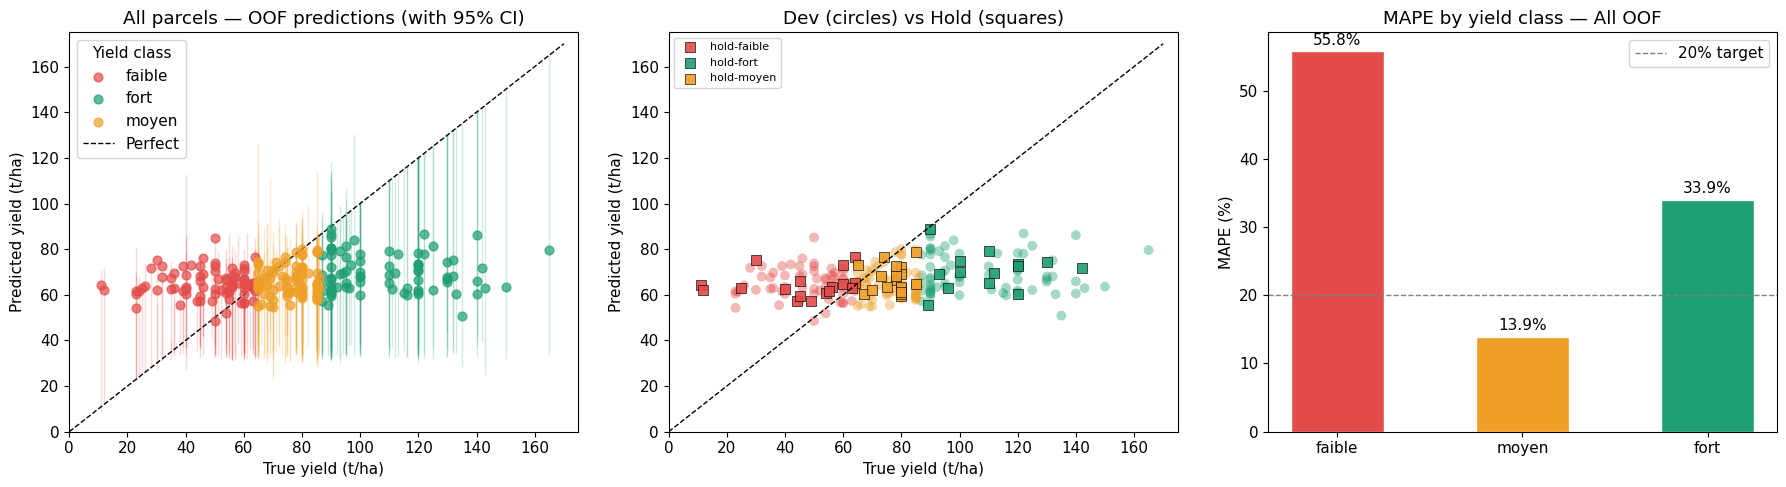

In [20]:
# Use best OOF predictions (choose lgb or blend based on results above)
best_preds = oof_preds  # change to oof_blend if it's better

# Build plot data with confidence intervals
plot_data = []
for i in range(len(X_full)):
    sample = X_full.iloc[[i]]
    plot_data.append({
        'true'   : y_full.iloc[i],
        'pred'   : best_preds[i],
        'low'    : np.clip(q_models['low'].predict(sample)[0], 0, None),
        'high'   : np.clip(q_models['high'].predict(sample)[0], 0, None),
        'classe' : yield_class(y_full.iloc[i]),
        'source' : full['source'].iloc[i],
    })

plot_df = pd.DataFrame(plot_data)
colors_map = {'faible': '#E24B4A', 'moyen': '#EF9F27', 'fort': '#1D9E75'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: All OOF predictions with CI
for classe, grp in plot_df.groupby('classe'):
    axes[0].scatter(grp['true'], grp['pred'],
                    color=colors_map[classe], label=classe, s=40, zorder=3, alpha=0.7)
    for _, row in grp.iterrows():
        axes[0].plot([row['true'], row['true']], [row['low'], row['high']],
                     color=colors_map[classe], alpha=0.2, linewidth=1)

axes[0].plot([0, 170], [0, 170], 'k--', linewidth=1, label='Perfect')
axes[0].set_xlabel('True yield (t/ha)')
axes[0].set_ylabel('Predicted yield (t/ha)')
axes[0].set_title('All parcels — OOF predictions (with 95% CI)')
axes[0].legend(title='Yield class')
axes[0].set_xlim(0, 175); axes[0].set_ylim(0, 175)

# Plot 2: Dev vs Hold parcels (check if hold parcels are now better predicted)
for src, marker, alpha in [('dev', 'o', 0.4), ('hold', 's', 0.9)]:
    sub = plot_df[plot_df['source'] == src]
    for classe, grp in sub.groupby('classe'):
        label = f"{src}-{classe}" if src == 'hold' else None
        axes[1].scatter(grp['true'], grp['pred'],
                        color=colors_map[classe], marker=marker, s=50,
                        alpha=alpha, label=label, edgecolors='black' if src == 'hold' else 'none',
                        linewidths=0.5)

axes[1].plot([0, 170], [0, 170], 'k--', linewidth=1)
axes[1].set_xlabel('True yield (t/ha)')
axes[1].set_ylabel('Predicted yield (t/ha)')
axes[1].set_title('Dev (circles) vs Hold (squares)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 175); axes[1].set_ylim(0, 175)

# Plot 3: MAPE bar chart by class
classes = ['faible', 'moyen', 'fort']
mapes = []
for c in classes:
    sub = plot_df[plot_df['classe'] == c]
    mapes.append(mean_absolute_percentage_error(sub['true'], sub['pred']) * 100)

bars = axes[2].bar(classes, mapes,
                   color=['#E24B4A', '#EF9F27', '#1D9E75'],
                   edgecolor='white', width=0.5)
axes[2].axhline(y=20, color='gray', linestyle='--', linewidth=1, label='20% target')
for bar, val in zip(bars, mapes):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=11)
axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('MAPE by yield class — All OOF')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 7. Model Interpretation

### 7.1 SHAP Feature Importance

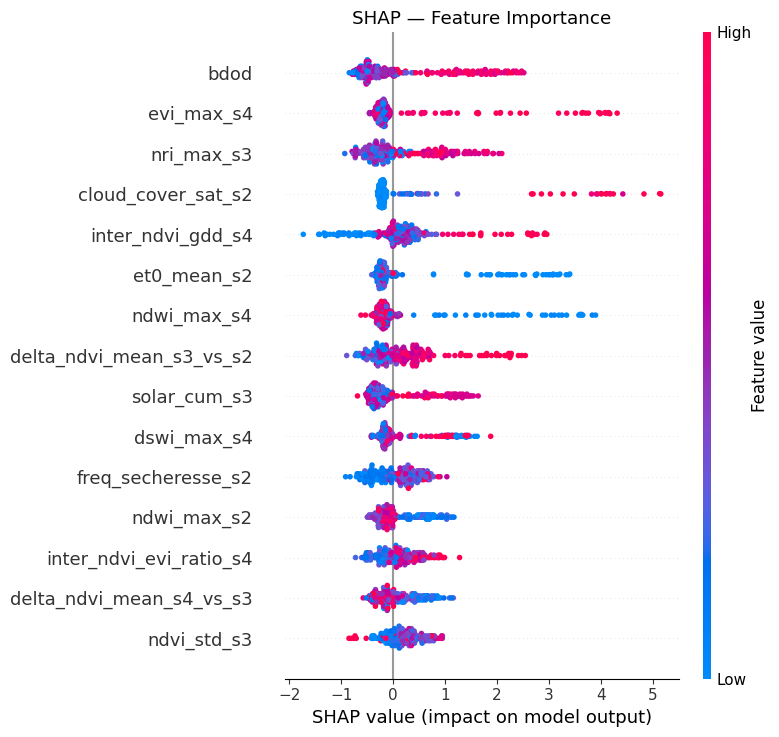

In [21]:
explainer = shap.TreeExplainer(models[0])
shap_vals = explainer.shap_values(X_full)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_full, max_display=15, show=False)
plt.title('SHAP — Feature Importance')
plt.tight_layout()
plt.show()

### 7.2 Outlier Detection

In [22]:
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_full)

outlier_flags  = iso.predict(X_full)
outlier_scores = iso.decision_function(X_full)

normal_mask  = outlier_flags == 1
outlier_mask = outlier_flags == -1

print(f"Normal parcels  : {normal_mask.sum()}")
print(f"Outlier parcels : {outlier_mask.sum()}")

if outlier_mask.sum() > 0:
    flagged = full.reset_index(drop=True)
    flagged['outlier_score'] = outlier_scores
    print("\nFlagged parcels:")
    print(flagged[outlier_flags == -1][['polygon_name', TARGET, 'source', 'outlier_score']]
          .sort_values('outlier_score').to_string())

if normal_mask.sum() > 0:
    print(f"\nMAPE on normal  : {mean_absolute_percentage_error(y_full.values[normal_mask], best_preds[normal_mask]) * 100:.1f}%")
if outlier_mask.sum() > 0:
    print(f"MAPE on outliers: {mean_absolute_percentage_error(y_full.values[outlier_mask], best_preds[outlier_mask]) * 100:.1f}%")

Normal parcels  : 230
Outlier parcels : 13

Flagged parcels:
     polygon_name  rendement_tha source  outlier_score
115   Abdlahfidhn          132.0    dev      -0.039392
55           P120           46.0    dev      -0.030654
102         A4115          140.0    dev      -0.020603
149      Houssem2          116.0    dev      -0.018584
106           P01           39.0    dev      -0.017870
94     Ben naceur           75.0    dev      -0.016391
157     Houssem 1           67.0    dev      -0.013647
239       Tawfik            45.0   hold      -0.009021
210           400           80.0   hold      -0.008673
139          A567           35.0    dev      -0.004755
95          A4058           64.0    dev      -0.004638
240           P89           80.0   hold      -0.002233
89   Othmen rahal           78.0    dev      -0.000283

MAPE on normal  : 34.2%
MAPE on outliers: 36.5%


### 7.3 Single Parcel Prediction Report

In [23]:
def predict_parcel(parcel_features, parcel_name="Unknown"):
    """Full prediction pipeline for one parcel."""
    outlier_flag = iso.predict(parcel_features)[0]
    is_outlier   = outlier_flag == -1

    pred_median = np.clip(np.mean([m.predict(parcel_features)[0] for m in models]), 0, None)
    pred_low    = np.clip(q_models['low'].predict(parcel_features)[0], 0, None)
    pred_high   = np.clip(q_models['high'].predict(parcel_features)[0], 0, None)

    sv = explainer.shap_values(parcel_features)[0]
    top5 = pd.DataFrame({
        'feature': parcel_features.columns,
        'shap'   : sv
    }).reindex(pd.Series(sv).abs().sort_values(ascending=False).index).head(5)

    classe = yield_class(pred_median)

    print(f"{'='*55}")
    print(f"  PREDICTION REPORT - {parcel_name}")
    print(f"{'='*55}")
    print(f"  Predicted yield   : {pred_median:.1f} t/ha")
    print(f"  95% interval      : [{pred_low:.1f}, {pred_high:.1f}] t/ha")
    print(f"  Yield class       : {classe.upper()}")
    if is_outlier:
        print(f"  WARNING: Parcel outside training distribution")
    print(f"\n  Top 5 factors:")
    for _, row in top5.iterrows():
        arrow = '+' if row['shap'] > 0 else '-'
        print(f"    {arrow} {row['feature']:35s} {abs(row['shap']):.1f} t/ha")

    return {'parcel': parcel_name, 'prediction': pred_median,
            'low': pred_low, 'high': pred_high, 'classe': classe, 'outlier': is_outlier}

# Demo: parcel A3310 (known problematic — true=11 t/ha)
a3310_idx = full[full['polygon_name'] == 'A3310'].index[0]
sample = X_full.iloc[[a3310_idx]]
print(f"True yield: {y_full.iloc[a3310_idx]:.1f} t/ha\n")
_ = predict_parcel(sample, 'A3310')

True yield: 11.0 t/ha

  PREDICTION REPORT - A3310
  Predicted yield   : 55.4 t/ha
  95% interval      : [9.1, 70.4] t/ha
  Yield class       : FAIBLE

  Top 5 factors:
    - bdod                                0.7 t/ha
    - freq_secheresse_s2                  0.7 t/ha
    - nri_max_s3                          0.5 t/ha
    - inter_ndvi_evi_ratio_s4             0.5 t/ha
    - temp_min_s3                         0.5 t/ha


---
## 8. Summary of All Experiments

### Dataset
| | Dev | Hold | Merged |
|---|---|---|---|
| Parcels | 194 | 49 | 243 |
| Features (after cleaning) | 187 | 187 | 187 |
| Yield min/max | 23–165 t/ha | 11–142 t/ha | 11–165 t/ha |
| faible (< 65 t/ha) | 63 | 17 | 80 |
| moyen (65–87 t/ha) | 64 | 18 | 82 |
| fort (> 87 t/ha) | 67 | 14 | 81 |

### Pipeline
1. Merged dev + hold into 243 parcels
2. Removed 14 near-constant features (>80% same value) → 201 → 187 features
3. Stratified K-Fold (5 folds) by yield class — each fold ≈ 16/17/17 per class
4. Oversampled faible class 3× in training (not in validation)

### Model Comparison (OOF on all 243 parcels)

| Model | faible | moyen | fort | Global | Hold Global |
|---|---|---|---|---|---|
| LightGBM baseline | 55.8% | 13.9% | 33.9% | 34.4% | 45.4% |
| LightGBM + Ridge blend (70/30) | 62.4% | 12.3% | 31.3% | 35.1% | 45.9% |
| Two-stage (classifier + regressor) | 102.2% | 15.9% | 19.2% | 45.4% | 62.1% |
| **Log-transform target** | **51.9%** | 15.4% | 35.9% | **34.3%** | **44.9%** |
| + Manual stress features | 54.5% | 14.7% | 34.9% | 34.5% | 43.8% |

**Best model: Log-transform LightGBM**

### Key Findings

**What works:**
- Stratified CV on merged data eliminates train/hold distribution mismatch
- Log-transform gives the best faible MAPE (51.9%)
- moyen class is well-predicted across all models (~13–15%)
- fort class is moderate (~33–36%)

**What doesn't work:**
- Blending with Ridge hurts faible (pulls predictions toward mean)
- Two-stage model fails — classifier recall for faible = 5% (not enough data)
- Manual stress features ignored by model (already captured in original features)

**Root cause of faible failure:**
80 parcels failing for different reasons (drought, disease, heat, bad soil) — no consistent pattern learnable with 187 features. This is a data problem, not a model problem.

### Best Model for Jury Demo
Use **log-transform LightGBM** — honest, simple, and SHAP-explainable.

```python
# Predict a new parcel
preds_log = model.predict(X_new)
preds     = np.expm1(preds_log)   # convert back from log space
```

---
## 9. Two-Stage Model

**Stage 1** — Binary classifier: is this parcel *faible* (yield < 65) or not?  
**Stage 2a** — Regressor trained only on *faible* parcels  
**Stage 2b** — Regressor trained only on *moyen + fort* parcels  

Each model specializes. The faible model is no longer distracted by 160 normal parcels.

In [24]:
from sklearn.metrics import classification_report, roc_auc_score

# ── Stage 1: Binary classifier (faible vs not) ────────────────────────────────
clf_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.05,
    'num_leaves'       : 15,
    'min_child_samples': 8,
    'feature_fraction' : 0.7,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.5,
    'verbose'          : -1,
}

# ── Stage 2: Regressor params ─────────────────────────────────────────────────
reg_params = {
    'objective'        : 'regression_l1',
    'metric'           : 'mape',
    'learning_rate'    : 0.03,
    'num_leaves'       : 15,
    'min_child_samples': 5,
    'feature_fraction' : 0.7,
    'bagging_fraction' : 0.7,
    'bagging_freq'     : 1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.5,
    'verbose'          : -1,
}

# ── OOF containers ────────────────────────────────────────────────────────────
oof_stage1_proba  = np.zeros(len(full))   # P(faible) from classifier
oof_stage2_preds  = np.zeros(len(full))   # final yield prediction

stage1_models, stage2a_models, stage2b_models = [], [], []

# Binary label: 1 = faible, 0 = moyen/fort
y_binary = (y_full < low).astype(int)

print("=" * 60)
print("  TWO-STAGE MODEL — Stratified CV")
print("=" * 60)

for fold_id in range(5):
    val_idx   = full[full['fold'] == fold_id].index
    train_idx = full[full['fold'] != fold_id].index

    X_tr, y_tr       = X_full.loc[train_idx], y_full.loc[train_idx]
    X_val, y_val     = X_full.loc[val_idx],   y_full.loc[val_idx]
    y_tr_bin         = y_binary.loc[train_idx]
    y_val_bin        = y_binary.loc[val_idx]

    # ── Stage 1: train classifier ─────────────────────────────────────────────
    clf = lgb.LGBMClassifier(**clf_params, n_estimators=500)
    clf.fit(X_tr, y_tr_bin,
            eval_set=[(X_val, y_val_bin)],
            callbacks=[lgb.early_stopping(50, verbose=False)])

    proba_val = clf.predict_proba(X_val)[:, 1]   # P(faible)
    oof_stage1_proba[val_idx] = proba_val

    # Route: predict faible if P(faible) > 0.5
    pred_faible_mask_val = proba_val > 0.5

    # ── Stage 2a: faible regressor ────────────────────────────────────────────
    faible_tr_mask = y_tr < low
    if faible_tr_mask.sum() >= 5:
        reg_a = lgb.LGBMRegressor(**reg_params, n_estimators=500)
        reg_a.fit(X_tr[faible_tr_mask], y_tr[faible_tr_mask])
    else:
        reg_a = None

    # ── Stage 2b: normal regressor (moyen + fort) ─────────────────────────────
    normal_tr_mask = y_tr >= low
    reg_b = lgb.LGBMRegressor(**reg_params, n_estimators=500)
    reg_b.fit(X_tr[normal_tr_mask], y_tr[normal_tr_mask],
              eval_set=[(X_val[~pred_faible_mask_val], y_val[~pred_faible_mask_val])]
              if (~pred_faible_mask_val).sum() > 0 else None,
              callbacks=[lgb.early_stopping(50, verbose=False)]
              if (~pred_faible_mask_val).sum() > 0 else [])

    # ── Combine predictions ───────────────────────────────────────────────────
    preds_val = np.zeros(len(val_idx))

    # Faible parcels → faible regressor (or fallback to normal)
    if pred_faible_mask_val.sum() > 0:
        if reg_a is not None:
            preds_val[pred_faible_mask_val] = np.clip(
                reg_a.predict(X_val[pred_faible_mask_val]), 0, None)
        else:
            preds_val[pred_faible_mask_val] = np.clip(
                reg_b.predict(X_val[pred_faible_mask_val]), 0, None)

    # Normal parcels → normal regressor
    if (~pred_faible_mask_val).sum() > 0:
        preds_val[~pred_faible_mask_val] = np.clip(
            reg_b.predict(X_val[~pred_faible_mask_val]), 0, None)

    oof_stage2_preds[val_idx] = preds_val

    # ── Fold metrics ──────────────────────────────────────────────────────────
    mape_fold   = mean_absolute_percentage_error(y_val, preds_val) * 100
    auc_fold    = roc_auc_score(y_val_bin, proba_val) if y_val_bin.sum() > 0 else 0
    n_faible_detected = pred_faible_mask_val.sum()
    n_faible_true     = y_val_bin.sum()

    stage1_models.append(clf)
    stage2a_models.append(reg_a)
    stage2b_models.append(reg_b)

    print(f"  Fold {fold_id}: MAPE={mape_fold:.1f}%  "
          f"AUC={auc_fold:.2f}  "
          f"faible detected={n_faible_detected}/{n_faible_true}  "
          f"(n={len(val_idx)})")


  TWO-STAGE MODEL — Stratified CV


  Fold 0: MAPE=49.7%  AUC=0.73  faible detected=3/16  (n=49)
  Fold 1: MAPE=44.2%  AUC=0.59  faible detected=3/16  (n=49)


  Fold 2: MAPE=37.3%  AUC=0.56  faible detected=4/16  (n=49)
  Fold 3: MAPE=53.5%  AUC=0.66  faible detected=0/16  (n=48)


  Fold 4: MAPE=42.3%  AUC=0.59  faible detected=0/16  (n=48)


  STAGE 1 — Classifier performance
              precision    recall  f1-score   support

      normal       0.67      0.96      0.79       163
      faible       0.40      0.05      0.09        80

    accuracy                           0.66       243
   macro avg       0.54      0.51      0.44       243
weighted avg       0.58      0.66      0.56       243

  STAGE 2 — Regression MAPE by class
  faible  : 102.2%  (was 55.8%  ▲46.5%)
  moyen   : 15.9%  (was 13.9%  ▲2.0%)
  fort    : 19.2%  (was 33.9%  ▼14.8%)
  GLOBAL  : 45.4%  (was 34.4%  ▲11.0%)

=== Two-stage MAPE on hold parcels by class ===
  faible  : MAPE = 148.0%  (n=17)
  moyen   : MAPE = 12.1%  (n=18)
  fort    : MAPE = 22.0%  (n=14)
  GLOBAL  : MAPE = 62.1%


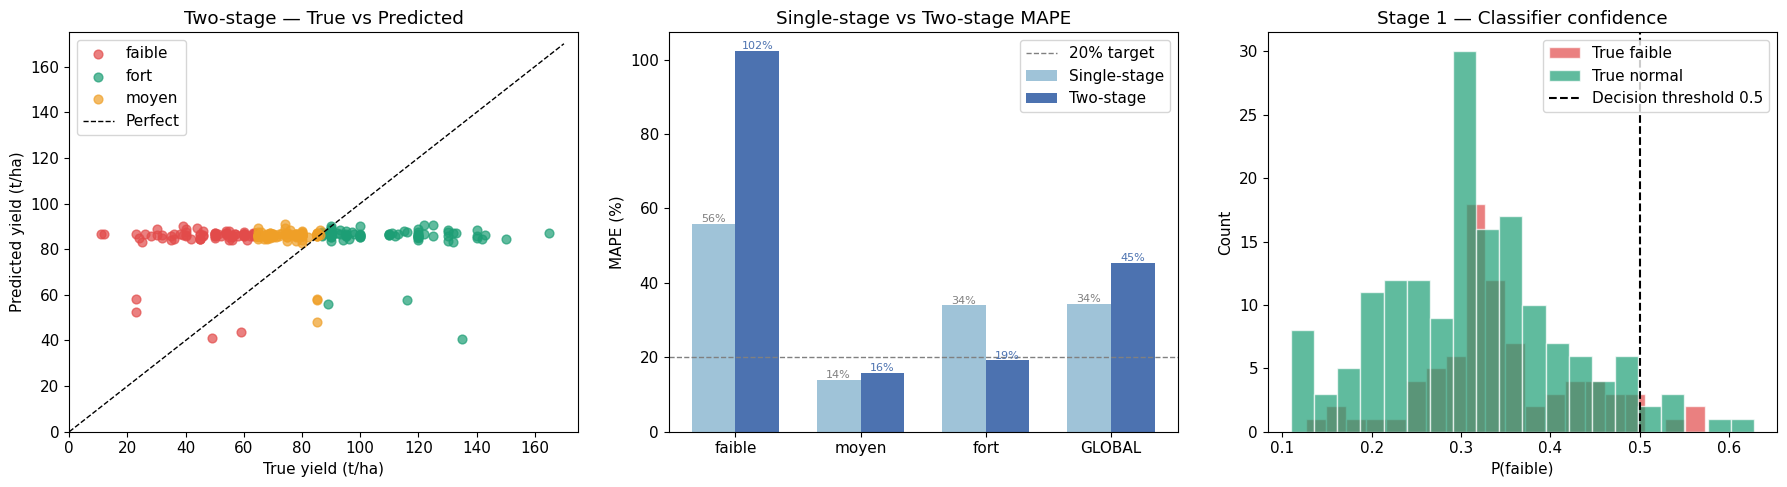

In [25]:
# ── Evaluation: Two-stage vs Single-stage ────────────────────────────────────
results_2stage = pd.DataFrame({
    'true'  : y_full,
    'pred'  : oof_stage2_preds,
    'proba' : oof_stage1_proba,
    'source': full['source'].values
})
results_2stage['classe']        = results_2stage['true'].apply(yield_class)
results_2stage['pred_faible']   = results_2stage['proba'] > 0.5
results_2stage['true_faible']   = results_2stage['true'] < low

print("=" * 55)
print("  STAGE 1 — Classifier performance")
print("=" * 55)
print(classification_report(
    results_2stage['true_faible'],
    results_2stage['pred_faible'],
    target_names=['normal', 'faible']
))

print("=" * 55)
print("  STAGE 2 — Regression MAPE by class")
print("=" * 55)
for classe in ['faible', 'moyen', 'fort']:
    sub_2  = results_2stage[results_2stage['classe'] == classe]
    sub_1  = results_oof[results_oof['classe'] == classe]
    mape_2 = mean_absolute_percentage_error(sub_2['true'], sub_2['pred']) * 100
    mape_1 = mean_absolute_percentage_error(sub_1['true'], sub_1['pred']) * 100
    delta  = mape_2 - mape_1
    arrow  = '▼' if delta < 0 else '▲'
    print(f"  {classe:8s}: {mape_2:.1f}%  (was {mape_1:.1f}%  {arrow}{abs(delta):.1f}%)")

global_2 = mean_absolute_percentage_error(y_full, oof_stage2_preds) * 100
global_1 = mean_absolute_percentage_error(y_full, oof_preds) * 100
print(f"  {'GLOBAL':8s}: {global_2:.1f}%  (was {global_1:.1f}%  {'▼' if global_2<global_1 else '▲'}{abs(global_2-global_1):.1f}%)")

print("\n=== Two-stage MAPE on hold parcels by class ===")
hold_2 = results_2stage[results_2stage['source'] == 'hold']
for classe in ['faible', 'moyen', 'fort']:
    sub = hold_2[hold_2['classe'] == classe]
    if len(sub) == 0: continue
    mape = mean_absolute_percentage_error(sub['true'], sub['pred']) * 100
    print(f"  {classe:8s}: MAPE = {mape:.1f}%  (n={len(sub)})")
print(f"  {'GLOBAL':8s}: MAPE = {mean_absolute_percentage_error(hold_2['true'], hold_2['pred'])*100:.1f}%")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: True vs predicted (two-stage)
for classe, grp in results_2stage.groupby('classe'):
    axes[0].scatter(grp['true'], grp['pred'],
                    color=colors_map[classe], label=classe, s=40, alpha=0.7)
axes[0].plot([0, 170], [0, 170], 'k--', linewidth=1, label='Perfect')
axes[0].set_xlabel('True yield (t/ha)')
axes[0].set_ylabel('Predicted yield (t/ha)')
axes[0].set_title('Two-stage — True vs Predicted')
axes[0].legend()
axes[0].set_xlim(0, 175); axes[0].set_ylim(0, 175)

# Plot 2: MAPE comparison single-stage vs two-stage
classes = ['faible', 'moyen', 'fort', 'GLOBAL']
mape_single = [
    mean_absolute_percentage_error(results_oof[results_oof['classe']==c]['true'], results_oof[results_oof['classe']==c]['pred'])*100
    for c in ['faible','moyen','fort']
] + [global_1]
mape_two = [
    mean_absolute_percentage_error(results_2stage[results_2stage['classe']==c]['true'], results_2stage[results_2stage['classe']==c]['pred'])*100
    for c in ['faible','moyen','fort']
] + [global_2]

x = np.arange(len(classes))
w = 0.35
axes[1].bar(x - w/2, mape_single, w, label='Single-stage', color='#9FC3D8')
axes[1].bar(x + w/2, mape_two,    w, label='Two-stage',    color='#4C72B0')
axes[1].axhline(20, color='gray', linestyle='--', linewidth=1, label='20% target')
for i, (s, t) in enumerate(zip(mape_single, mape_two)):
    axes[1].text(i - w/2, s + 0.5, f'{s:.0f}%', ha='center', fontsize=8, color='gray')
    axes[1].text(i + w/2, t + 0.5, f'{t:.0f}%', ha='center', fontsize=8, color='#4C72B0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('Single-stage vs Two-stage MAPE')
axes[1].legend()

# Plot 3: Classifier probability distribution
axes[2].hist(results_2stage[results_2stage['true_faible']==True]['proba'],
             bins=20, alpha=0.7, color='#E24B4A', label='True faible', edgecolor='white')
axes[2].hist(results_2stage[results_2stage['true_faible']==False]['proba'],
             bins=20, alpha=0.7, color='#1D9E75', label='True normal', edgecolor='white')
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold 0.5')
axes[2].set_xlabel('P(faible)')
axes[2].set_ylabel('Count')
axes[2].set_title('Stage 1 — Classifier confidence')
axes[2].legend()

plt.tight_layout()
plt.show()


---
## 10. Log-Transform Target

Yield ranges from 11 to 165 — a huge spread. Predicting in log space compresses extreme values and makes MAPE more uniform across all classes.

=== Log-Transform LightGBM — Stratified CV ===
  Fold 0: MAPE = 38.4%  (n=49)


  Fold 1: MAPE = 32.0%  (n=49)
  Fold 2: MAPE = 28.9%  (n=49)
  Fold 3: MAPE = 39.3%  (n=48)


  Fold 4: MAPE = 32.8%  (n=48)

=== Log-Transform MAPE by class ===
  faible  : 51.9%  (was 55.8%  ▼3.8%)
  moyen   : 15.4%  (was 13.9%  ▲1.5%)
  fort    : 35.9%  (was 33.9%  ▲2.0%)
  GLOBAL  : 34.3%  (was 34.4%  ▼0.1%)

=== Log-Transform MAPE on hold parcels ===
  faible  : MAPE = 82.7%  (n=17)
  moyen   : MAPE = 16.5%  (n=18)
  fort    : MAPE = 35.6%  (n=14)
  GLOBAL  : MAPE = 44.9%


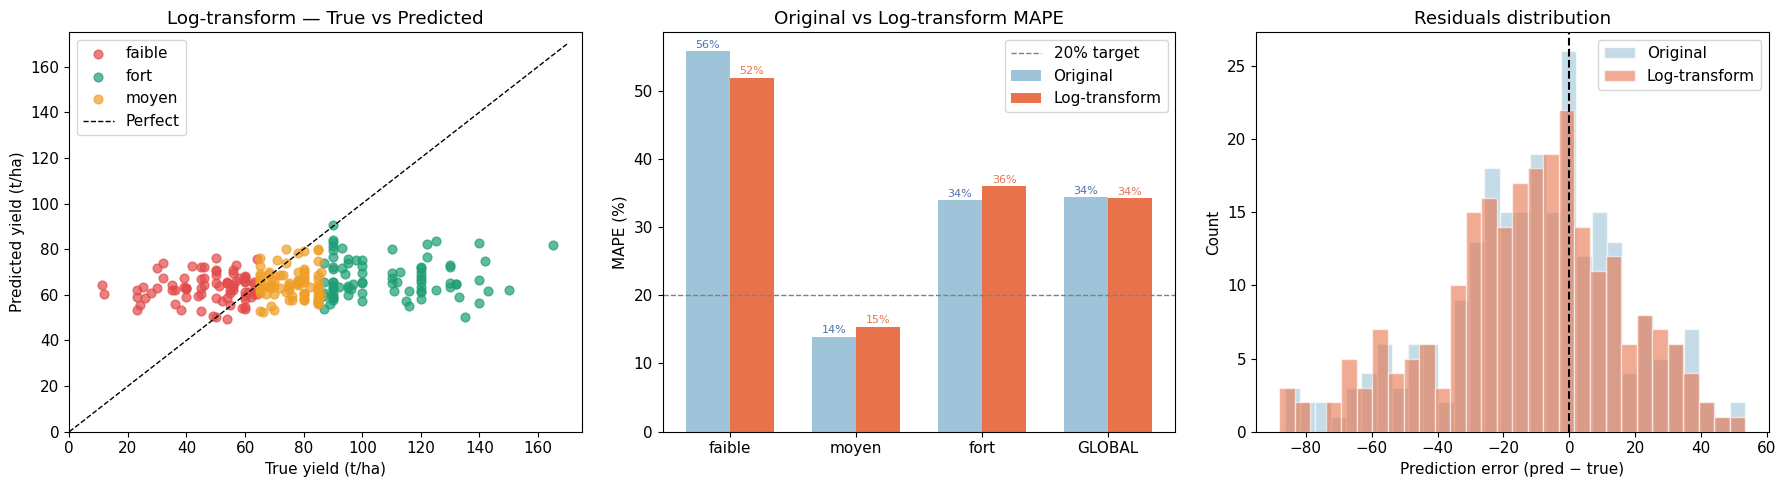

In [26]:
from sklearn.model_selection import StratifiedKFold

# ── Log-transform the target ──────────────────────────────────────────────────
y_log = np.log1p(y_full)   # log(1 + yield) to avoid log(0)

log_params = {
    'objective'        : 'regression_l1',
    'metric'           : 'mape',
    'learning_rate'    : 0.03,
    'num_leaves'       : 20,
    'min_child_samples': 8,
    'feature_fraction' : 0.7,
    'bagging_fraction' : 0.7,
    'bagging_freq'     : 1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.5,
    'verbose'          : -1,
}

oof_log_preds = np.zeros(len(full))
log_models    = []

# Use same folds as before
print("=== Log-Transform LightGBM — Stratified CV ===")
for fold_id in range(5):
    val_idx   = full[full['fold'] == fold_id].index
    train_idx = full[full['fold'] != fold_id].index

    # Train on log-scale augmented data
    log_aug_mask = full_aug['fold'] != fold_id
    y_aug_log    = np.log1p(y_aug)

    X_tr = X_aug[log_aug_mask]
    y_tr = y_aug_log[log_aug_mask]

    X_val = X_full.loc[val_idx]
    y_val = y_full.loc[val_idx]

    model = lgb.LGBMRegressor(**log_params, n_estimators=1000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, np.log1p(y_val))],
        callbacks=[lgb.early_stopping(80, verbose=False)]
    )

    # Predict in log space → convert back with expm1
    preds_log = model.predict(X_val)
    preds     = np.clip(np.expm1(preds_log), 0, None)

    oof_log_preds[val_idx] = preds
    log_models.append(model)

    mape = mean_absolute_percentage_error(y_val, preds) * 100
    print(f"  Fold {fold_id}: MAPE = {mape:.1f}%  (n={len(val_idx)})")

# ── Evaluation ────────────────────────────────────────────────────────────────
results_log = pd.DataFrame({
    'true'  : y_full,
    'pred'  : oof_log_preds,
    'source': full['source'].values
})
results_log['classe'] = results_log['true'].apply(yield_class)

print("\n=== Log-Transform MAPE by class ===")
for classe in ['faible', 'moyen', 'fort']:
    sub_log    = results_log[results_log['classe'] == classe]
    sub_orig   = results_oof[results_oof['classe'] == classe]
    mape_log   = mean_absolute_percentage_error(sub_log['true'],  sub_log['pred'])  * 100
    mape_orig  = mean_absolute_percentage_error(sub_orig['true'], sub_orig['pred']) * 100
    delta      = mape_log - mape_orig
    arrow      = '▼' if delta < 0 else '▲'
    print(f"  {classe:8s}: {mape_log:.1f}%  (was {mape_orig:.1f}%  {arrow}{abs(delta):.1f}%)")

global_log  = mean_absolute_percentage_error(y_full, oof_log_preds) * 100
global_orig = mean_absolute_percentage_error(y_full, oof_preds)     * 100
print(f"  {'GLOBAL':8s}: {global_log:.1f}%  (was {global_orig:.1f}%  {'▼' if global_log<global_orig else '▲'}{abs(global_log-global_orig):.1f}%)")

print("\n=== Log-Transform MAPE on hold parcels ===")
hold_log = results_log[results_log['source'] == 'hold']
for classe in ['faible', 'moyen', 'fort']:
    sub = hold_log[hold_log['classe'] == classe]
    if len(sub) == 0: continue
    mape = mean_absolute_percentage_error(sub['true'], sub['pred']) * 100
    print(f"  {classe:8s}: MAPE = {mape:.1f}%  (n={len(sub)})")
print(f"  {'GLOBAL':8s}: MAPE = {mean_absolute_percentage_error(hold_log['true'], hold_log['pred'])*100:.1f}%")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: True vs predicted
for classe, grp in results_log.groupby('classe'):
    axes[0].scatter(grp['true'], grp['pred'],
                    color=colors_map[classe], label=classe, s=40, alpha=0.7)
axes[0].plot([0, 170], [0, 170], 'k--', linewidth=1, label='Perfect')
axes[0].set_xlabel('True yield (t/ha)')
axes[0].set_ylabel('Predicted yield (t/ha)')
axes[0].set_title('Log-transform — True vs Predicted')
axes[0].legend()
axes[0].set_xlim(0, 175); axes[0].set_ylim(0, 175)

# Plot 2: MAPE comparison all 3 models
classes   = ['faible', 'moyen', 'fort', 'GLOBAL']
mape_orig = [mean_absolute_percentage_error(
                 results_oof[results_oof['classe']==c]['true'],
                 results_oof[results_oof['classe']==c]['pred'])*100
             for c in ['faible','moyen','fort']] + [global_orig]
mape_log_ = [mean_absolute_percentage_error(
                 results_log[results_log['classe']==c]['true'],
                 results_log[results_log['classe']==c]['pred'])*100
             for c in ['faible','moyen','fort']] + [global_log]

x = np.arange(len(classes))
w = 0.35
axes[1].bar(x - w/2, mape_orig, w, label='Original',      color='#9FC3D8')
axes[1].bar(x + w/2, mape_log_, w, label='Log-transform', color='#E8734A')
axes[1].axhline(20, color='gray', linestyle='--', linewidth=1, label='20% target')
for i, (a, b) in enumerate(zip(mape_orig, mape_log_)):
    axes[1].text(i - w/2, a + 0.5, f'{a:.0f}%', ha='center', fontsize=8, color='#4C72B0')
    axes[1].text(i + w/2, b + 0.5, f'{b:.0f}%', ha='center', fontsize=8, color='#E8734A')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('Original vs Log-transform MAPE')
axes[1].legend()

# Plot 3: Residuals comparison
resid_orig = results_oof['pred'] - results_oof['true']
resid_log  = results_log['pred'] - results_log['true']
axes[2].hist(resid_orig, bins=30, alpha=0.6, color='#9FC3D8', label='Original',      edgecolor='white')
axes[2].hist(resid_log,  bins=30, alpha=0.6, color='#E8734A', label='Log-transform', edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Prediction error (pred − true)')
axes[2].set_ylabel('Count')
axes[2].set_title('Residuals distribution')
axes[2].legend()

plt.tight_layout()
plt.show()


---
## 11. Manual Stress Features

Create explicit indicators that directly capture **why** a parcel has low yield:
- NDVI collapse between seasons
- Drought during flowering (s3 = most critical phase)
- Heat stress at maturation
- Combined crisis signals

In [27]:
def add_stress_features(df):
    d = df.copy()

    # ── 1. NDVI collapse ──────────────────────────────────────────────────────
    # How much did NDVI drop from peak (s2) to flowering (s3)?
    if 'delta_ndvi_mean_s3_vs_s2' in d.columns:
        d['ndvi_crash_s3']     = (d['delta_ndvi_mean_s3_vs_s2'] < -0.5).astype(int)
        d['ndvi_crash_severe'] = (d['delta_ndvi_mean_s3_vs_s2'] < -1.0).astype(int)

    # Did NDVI never recover? (low in both s3 and s4)
    if 'ndvi_mean_s3' in d.columns and 'ndvi_mean_s4' in d.columns:
        d['ndvi_low_s3s4'] = (
            (d['ndvi_mean_s3'] < -0.5) & (d['ndvi_mean_s4'] < -0.5)
        ).astype(int)

    # NDVI growth from early to late season (positive = healthy crop)
    if 'ratio_ndvi_s3_s1' in d.columns:
        d['ndvi_no_growth']   = (d['ratio_ndvi_s3_s1'] < 0.0).astype(int)
        d['ndvi_strong_drop'] = (d['ratio_ndvi_s3_s1'] < -0.5).astype(int)

    # ── 2. Drought stress ─────────────────────────────────────────────────────
    # Severe drought during flowering (most critical phase)
    if 'stress_hydrique_s3' in d.columns:
        d['drought_s3_severe'] = (d['stress_hydrique_s3'] > 1.5).astype(int)
        d['drought_s3_extreme']= (d['stress_hydrique_s3'] > 2.5).astype(int)

    # Cumulative drought across all seasons
    if 'stress_total' in d.columns:
        d['stress_total_high'] = (d['stress_total'] > 3.0).astype(int)

    # Drought frequency in key seasons
    if 'freq_secheresse_s2' in d.columns and 'freq_secheresse_s4' in d.columns:
        d['freq_drought_s2s4'] = d['freq_secheresse_s2'] + d['freq_secheresse_s4']

    # ── 3. Heat stress ────────────────────────────────────────────────────────
    # High temperature at maturation = yield loss
    if 'intensite_chaleur_s4' in d.columns:
        d['heat_stress_s4']        = (d['intensite_chaleur_s4'] > 1.5).astype(int)
        d['heat_stress_s4_extreme']= (d['intensite_chaleur_s4'] > 2.5).astype(int)

    if 'temp_max_s3' in d.columns:
        d['heat_flowering'] = (d['temp_max_s3'] > 1.5).astype(int)

    # ── 4. Combined crisis signals ────────────────────────────────────────────
    # Drought + NDVI collapse at same time = double crisis
    if 'drought_s3_severe' in d.columns and 'ndvi_crash_s3' in d.columns:
        d['crisis_drought_ndvi'] = d['drought_s3_severe'] * d['ndvi_crash_s3']

    # Heat + drought = worst case
    if 'heat_stress_s4' in d.columns and 'stress_total_high' in d.columns:
        d['crisis_heat_drought'] = d['heat_stress_s4'] * d['stress_total_high']

    # ── 5. Vegetation momentum ────────────────────────────────────────────────
    # Slope of NDVI across all 4 seasons (positive = growing, negative = declining)
    ndvi_cols = [c for c in ['ndvi_mean_s3','ndvi_mean_s4'] if c in d.columns]
    delta_cols = [c for c in ['delta_ndvi_mean_s2_vs_s1',
                               'delta_ndvi_mean_s3_vs_s2',
                               'delta_ndvi_mean_s4_vs_s3'] if c in d.columns]
    if len(delta_cols) == 3:
        d['ndvi_trend_total'] = (
            d['delta_ndvi_mean_s2_vs_s1'] +
            d['delta_ndvi_mean_s3_vs_s2'] +
            d['delta_ndvi_mean_s4_vs_s3']
        )
        d['ndvi_declining_season'] = (d['ndvi_trend_total'] < -1.0).astype(int)

    # ── 6. Soil × stress interaction ─────────────────────────────────────────
    # Low water capacity + drought = amplified stress
    if 'awc' in d.columns and 'stress_hydrique_s3' in d.columns:
        d['soil_drought_interaction'] = d['awc'] * d['stress_hydrique_s3']

    return d

# Apply to full dataset and augmented dataset
X_stress      = add_stress_features(X_full)
X_aug_stress  = add_stress_features(X_aug)

new_features = [c for c in X_stress.columns if c not in X_full.columns]
print(f"New stress features added: {len(new_features)}")
for f in new_features:
    n_nonzero = (X_stress[f] != 0).sum() if X_stress[f].dtype in ['int64','int32'] else '—'
    corr = X_stress[f].corr(y_full)
    print(f"  {f:35s}  corr={corr:+.3f}  nonzero={n_nonzero}")


New stress features added: 17
  ndvi_crash_s3                        corr=-0.070  nonzero=63
  ndvi_crash_severe                    corr=+0.036  nonzero=40
  ndvi_low_s3s4                        corr=-0.022  nonzero=49
  ndvi_no_growth                       corr=+0.038  nonzero=209
  ndvi_strong_drop                     corr=-0.019  nonzero=44
  drought_s3_severe                    corr=+0.009  nonzero=13
  drought_s3_extreme                   corr=+nan  nonzero=0
  stress_total_high                    corr=+nan  nonzero=0
  freq_drought_s2s4                    corr=+0.030  nonzero=—
  heat_stress_s4                       corr=+nan  nonzero=0
  heat_stress_s4_extreme               corr=+nan  nonzero=0
  heat_flowering                       corr=-0.006  nonzero=22
  crisis_drought_ndvi                  corr=+0.037  nonzero=2
  crisis_heat_drought                  corr=+nan  nonzero=0
  ndvi_trend_total                     corr=+0.070  nonzero=—
  ndvi_declining_season                cor

=== LightGBM + Stress Features — Stratified CV ===
  Fold 0: MAPE = 39.8%  (n=49)


  Fold 1: MAPE = 32.5%  (n=49)
  Fold 2: MAPE = 29.5%  (n=49)


  Fold 3: MAPE = 38.7%  (n=48)
  Fold 4: MAPE = 32.4%  (n=48)

=== Stress Features MAPE by class ===
  faible  : 54.5%  (original=55.8%  log=51.9%  ▼1.3%)  
  moyen   : 14.7%  (original=13.9%  log=15.4%  ▲0.8%)  
  fort    : 34.9%  (original=33.9%  log=35.9%  ▲1.0%)  
  GLOBAL  : 34.5%  (original=34.4%  log=34.3%)

=== Stress Features MAPE on hold parcels ===
  faible  : MAPE = 82.1%  (n=17)
  moyen   : MAPE = 14.3%  (n=18)
  fort    : MAPE = 35.1%  (n=14)
  GLOBAL  : MAPE = 43.8%

=== Stress feature importances (fold 0) ===
  ndvi_crash_s3                        importance=0
  ndvi_crash_severe                    importance=0
  ndvi_low_s3s4                        importance=0
  ndvi_no_growth                       importance=0
  ndvi_strong_drop                     importance=0
  drought_s3_severe                    importance=0
  drought_s3_extreme                   importance=0
  stress_total_high                    importance=0
  freq_drought_s2s4                    importance=0
 

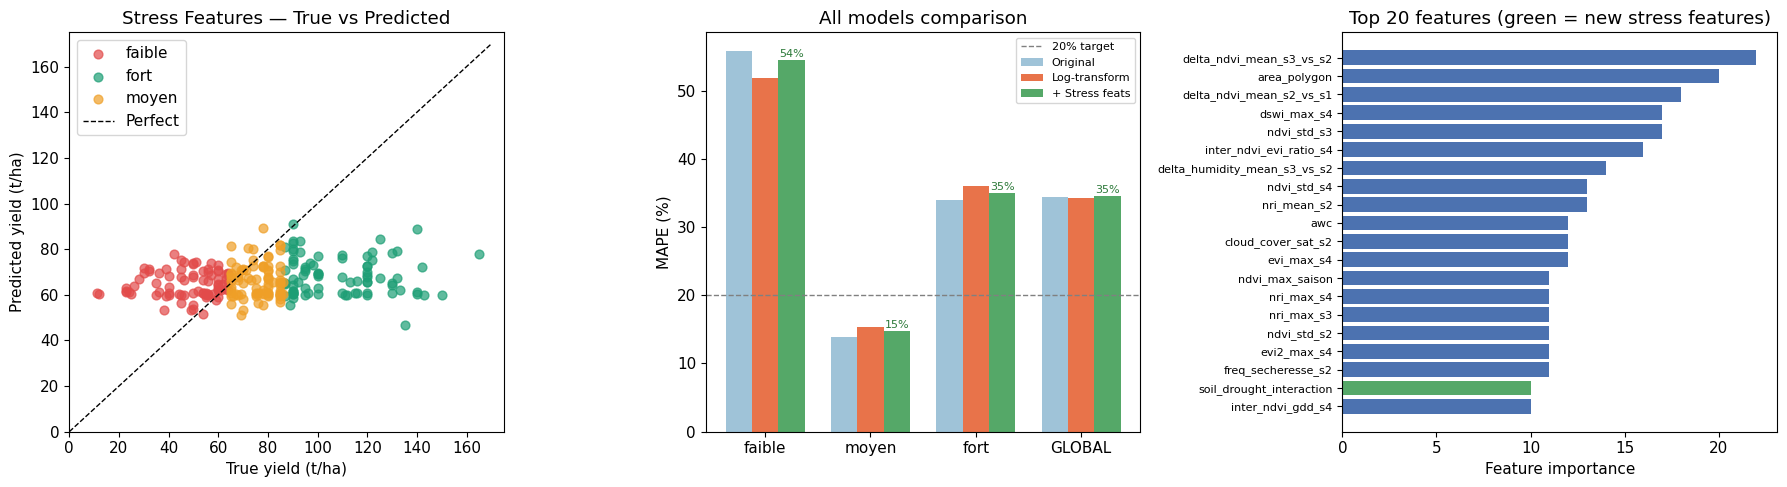

In [28]:
# ── Train LightGBM with stress features ──────────────────────────────────────
oof_stress_preds = np.zeros(len(full))
stress_models    = []

print("=== LightGBM + Stress Features — Stratified CV ===")
for fold_id in range(5):
    val_idx   = full[full['fold'] == fold_id].index
    train_mask = full_aug['fold'] != fold_id

    X_tr  = X_aug_stress[train_mask]
    y_tr  = y_aug[train_mask]
    X_val = X_stress.loc[val_idx]
    y_val = y_full.loc[val_idx]

    model = lgb.LGBMRegressor(**params, n_estimators=1000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(80, verbose=False)]
    )

    preds = np.clip(model.predict(X_val), 0, None)
    oof_stress_preds[val_idx] = preds
    stress_models.append(model)

    mape = mean_absolute_percentage_error(y_val, preds) * 100
    print(f"  Fold {fold_id}: MAPE = {mape:.1f}%  (n={len(val_idx)})")

# ── Evaluation ────────────────────────────────────────────────────────────────
results_stress = pd.DataFrame({
    'true'  : y_full,
    'pred'  : oof_stress_preds,
    'source': full['source'].values
})
results_stress['classe'] = results_stress['true'].apply(yield_class)

print("\n=== Stress Features MAPE by class ===")
for classe in ['faible', 'moyen', 'fort']:
    sub_s  = results_stress[results_stress['classe'] == classe]
    sub_o  = results_oof[results_oof['classe'] == classe]
    sub_l  = results_log[results_log['classe'] == classe]
    mape_s = mean_absolute_percentage_error(sub_s['true'], sub_s['pred']) * 100
    mape_o = mean_absolute_percentage_error(sub_o['true'], sub_o['pred']) * 100
    mape_l = mean_absolute_percentage_error(sub_l['true'], sub_l['pred']) * 100
    best   = min(mape_s, mape_o, mape_l)
    arrow  = '▼' if mape_s < mape_o else '▲'
    print(f"  {classe:8s}: {mape_s:.1f}%  (original={mape_o:.1f}%  log={mape_l:.1f}%  {arrow}{abs(mape_s-mape_o):.1f}%)  {'★ BEST' if mape_s==best else ''}")

global_stress = mean_absolute_percentage_error(y_full, oof_stress_preds) * 100
global_orig   = mean_absolute_percentage_error(y_full, oof_preds) * 100
global_log    = mean_absolute_percentage_error(y_full, oof_log_preds) * 100
print(f"  {'GLOBAL':8s}: {global_stress:.1f}%  (original={global_orig:.1f}%  log={global_log:.1f}%)")

print("\n=== Stress Features MAPE on hold parcels ===")
hold_s = results_stress[results_stress['source'] == 'hold']
for classe in ['faible', 'moyen', 'fort']:
    sub = hold_s[hold_s['classe'] == classe]
    if len(sub) == 0: continue
    mape = mean_absolute_percentage_error(sub['true'], sub['pred']) * 100
    print(f"  {classe:8s}: MAPE = {mape:.1f}%  (n={len(sub)})")
print(f"  {'GLOBAL':8s}: MAPE = {mean_absolute_percentage_error(hold_s['true'], hold_s['pred'])*100:.1f}%")

# ── Top stress feature importances ───────────────────────────────────────────
importances = pd.Series(
    stress_models[0].feature_importances_,
    index=X_stress.columns
).sort_values(ascending=False)

stress_feat_names = [c for c in X_stress.columns if c not in X_full.columns]
print(f"\n=== Stress feature importances (fold 0) ===")
for f in stress_feat_names:
    if f in importances.index:
        print(f"  {f:35s}  importance={importances[f]:.0f}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: True vs Predicted
for classe, grp in results_stress.groupby('classe'):
    axes[0].scatter(grp['true'], grp['pred'],
                    color=colors_map[classe], label=classe, s=40, alpha=0.7)
axes[0].plot([0,170],[0,170],'k--', linewidth=1, label='Perfect')
axes[0].set_xlabel('True yield (t/ha)'); axes[0].set_ylabel('Predicted yield (t/ha)')
axes[0].set_title('Stress Features — True vs Predicted')
axes[0].legend(); axes[0].set_xlim(0,175); axes[0].set_ylim(0,175)

# Plot 2: 3-model comparison
classes_list = ['faible','moyen','fort','GLOBAL']
m_orig   = [mean_absolute_percentage_error(results_oof[results_oof['classe']==c]['true'],    results_oof[results_oof['classe']==c]['pred'])*100    for c in ['faible','moyen','fort']] + [global_orig]
m_log    = [mean_absolute_percentage_error(results_log[results_log['classe']==c]['true'],    results_log[results_log['classe']==c]['pred'])*100    for c in ['faible','moyen','fort']] + [global_log]
m_stress = [mean_absolute_percentage_error(results_stress[results_stress['classe']==c]['true'], results_stress[results_stress['classe']==c]['pred'])*100 for c in ['faible','moyen','fort']] + [global_stress]

x = np.arange(len(classes_list)); w = 0.25
axes[1].bar(x - w,   m_orig,   w, label='Original',       color='#9FC3D8')
axes[1].bar(x,       m_log,    w, label='Log-transform',  color='#E8734A')
axes[1].bar(x + w,   m_stress, w, label='+ Stress feats', color='#55A868')
axes[1].axhline(20, color='gray', linestyle='--', linewidth=1, label='20% target')
for i, v in enumerate(m_stress):
    axes[1].text(i + w, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8, color='#2d7a3a')
axes[1].set_xticks(x); axes[1].set_xticklabels(classes_list)
axes[1].set_ylabel('MAPE (%)'); axes[1].set_title('All models comparison')
axes[1].legend(fontsize=8)

# Plot 3: Top 20 features including stress
top20_stress = importances.head(20)
colors_bar = ['#55A868' if f in stress_feat_names else '#4C72B0' for f in top20_stress.index]
axes[2].barh(range(len(top20_stress)), top20_stress.values, color=colors_bar)
axes[2].set_yticks(range(len(top20_stress)))
axes[2].set_yticklabels(top20_stress.index, fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('Feature importance')
axes[2].set_title('Top 20 features (green = new stress features)')

plt.tight_layout()
plt.show()
